<a href="https://colab.research.google.com/github/ifarooq7/ml-with-python/blob/main/Regression_Housepricing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
The Boston Housing dataset, which is used in regression analysis,
provides insights into the housing values in the suburbs of Boston.

'''

'\nThe Boston Housing dataset, which is used in regression analysis,\nprovides insights into the housing values in the suburbs of Boston.\n\n'

In [15]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import RandomForestClassifier#

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt



In [19]:
# -----------------------------
# Load dataset
# -----------------------------
data_url = 'https://lib.stat.cmu.edu/datasets/boston'
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# The dataset is structured such that each data point spans two lines.
# We need to combine every two rows from the raw_df into one.
# The first line has 11 features, the second line has the remaining 2 features and the target.
data = []
for i in range(0, len(raw_df), 2):
    line1 = raw_df.iloc[i].dropna().tolist() # First 11 features
    line2 = raw_df.iloc[i+1].dropna().tolist() # Next 2 features and target
    data.append(line1 + line2)

df = pd.DataFrame(data)

# Define column names based on the dataset description
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
    'B', 'LSTAT', 'MEDV'
]
df.columns = column_names
print(df)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

In [18]:
# here are the descriptions of above Features
# We need to talk about Feature engineering here. Many features here in the list are derived features.
columns = [
    "crime_rate",                  # CRIM → Per capita crime rate
    "residential_land_ratio",     # ZN → % land zoned for large residential lots
    "industrial_land_ratio",      # INDUS → % non-retail/industrial land
    "near_river",                 # CHAS → 1 if near Charles River, else 0
    "pollution_nox",              # NOX → Nitric oxide concentration
    "avg_rooms",                  # RM → Average number of rooms per dwelling
    "old_home_ratio",             # AGE → % homes built before 1940
    "distance_to_jobs",           # DIS → Distance to employment centers
    "highway_access_index",       # RAD → Accessibility to highways
    "property_tax_rate",          # TAX → Property tax rate
    "pupil_teacher_ratio",        # PTRATIO → School ratio
    "race_score_index",           # B → Derived demographic index (⚠️ sensitive)
    "lower_status_population_pct" # LSTAT → % lower socioeconomic population
]
#
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


In [16]:
# -----------------------------
# Features & Target
# -----------------------------
#   "MEDV Median value of owner-occupied homes (in $1000s)"

X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [ ]:
# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# -----------------------------
# Model: Random Forest Regression
# Why we are not using linear regression - the most common model. Data is complex and non-linear relationships.
# -----------------------------
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

In [24]:
# -----------------------------
# Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Evaluation:
MAE: 2.0395392156862746
MSE: 7.901513892156864
RMSE: 2.8109631609391226
R2 Score: 0.8922527442109116


173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: MEDV, Length: 102, dtype: float64
[22.839 30.676 16.317 23.51  16.819 21.374 19.358 15.62  21.091 21.073
 20.047 19.297  8.611 21.398 19.378 25.453 19.187  8.538 46.132 14.536
 24.728 23.996 14.509 23.847 14.363 14.796 21.126 13.663 19.535 21.29
 19.449 23.393 29.3   20.338 14.596 15.594 33.835 19.123 20.915 24.376
 19.286 29.61  46.108 19.428 22.653 13.676 15.035 24.321 18.689 28.821
 21.107 33.811 16.502 25.779 44.922 21.982 15.416 32.032 22.596 20.296
 25.611 33.916 28.134 18.551 26.745 17.568 13.992 23.195 29.022 15.663
 21.074 27.426 10.06  21.569 21.952  7.084 19.905 46.154 11.274 12.981
 21.288 12.562 19.561  9.392 20.76  27.283 15.383 23.399 23.628 17.617
 21.68   8.019 19.616 18.714 22.592 19.786 41.733 12.79  12.726 13.119
 20.603 23.902]


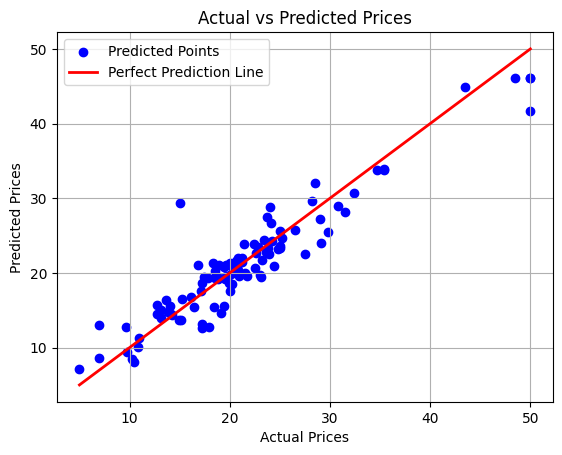

In [25]:
# -----------------------------
# Visualization
# -----------------------------
'''
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()
'''
# -----------------------------
# Visualization (Colored)
# -----------------------------
plt.figure()

# Scatter plot with color
plt.scatter(y_test, y_pred, color='blue', label='Predicted Points')
print(y_test)
print(y_pred)

# Ideal line (Actual = Predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    label='Perfect Prediction Line'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.legend()
plt.grid(True)

plt.show()

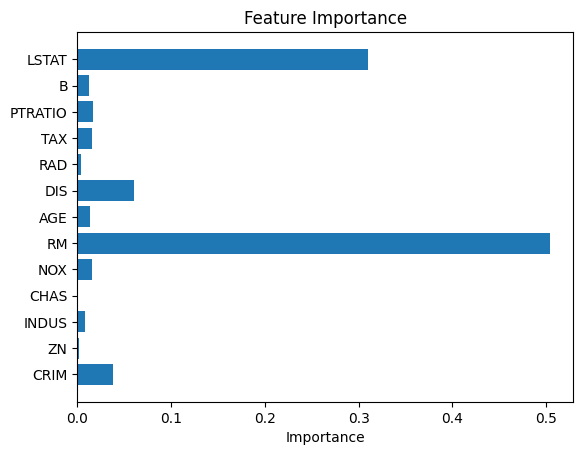

In [ ]:
# -----------------------------
# Feature Importance
# -----------------------------
importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()